## **Lo que van a encontrar en este notebook**

Tenemos dos metas:

1. Ver ejemplos de agrupamiento topologico utilizando $\varepsilon$-grafos y $k$-vecinos mas cercanos.

2. Utilizar lo aprendido para hacer un buen agrupamento del conjunto de digitos (clase = 1).

Completar las actividades marcadas con **Hacer** o **Tu Respuesta**. Sugiero leer atentamente el codigo y los comentarios para tener una idea de que esta pasando

---

En python es usual importar todas las librerias necesarias al principio.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn.datasets import make_moons

from scipy.sparse.csgraph import connected_components

from sklearn.neighbors import radius_neighbors_graph
from sklearn.neighbors import kneighbors_graph

### **1. Ejemplo de agrupamiento topologico**

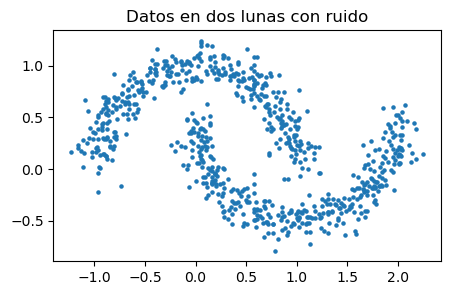

In [2]:
# Primero generamos un conjunto de datos en dos lunas con un poco de ruido
X, _ = make_moons(n_samples=750, noise=0.1, random_state=42)

# Graficamos los datos para tener una mejor idea
plt.figure(figsize =  (5,3))
plt.scatter(X[:, 0], X[:, 1], s= 5);
plt.title('Datos en dos lunas con ruido')
plt.show()

### Agrupamiento con $\varepsilon$-grafos.

**Hacer:** En la celda de abajo, selecciona un valor de $\varepsilon > 0$ apropiado de tal forma que las componentes arco-conexas de $G_\varepsilon(X)$, denotadas con colores, correspondan a las dos lunas.




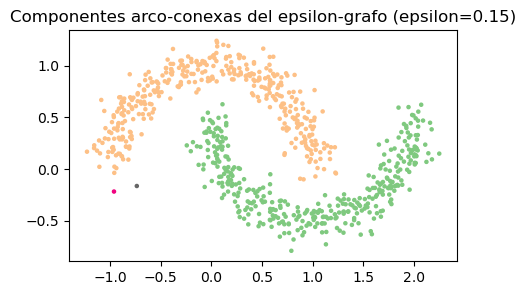

Numero de componentes encontradas: 4


In [3]:
epsilon = 0.15 # Slecciona un valor de epsilon apropiado

# Esta linea calcula la matriz de adyacencia del epsilon-grafo
adjacency_matrix = radius_neighbors_graph(X, epsilon).toarray()

# Ahora calculamos las componentes arco-conexas resultantes
n_components, cluster_labels = connected_components(adjacency_matrix, directed=False, return_labels=True)

# Finalmente, graficamos los puntos coloreados por su componente arco-conexa
plt.figure(figsize=(5, 3))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, s = 5, cmap='Accent')
plt.title(f'Componentes arco-conexas del epsilon-grafo (epsilon={epsilon})')
plt.show()
print(f'Numero de componentes encontradas: {n_components}')


---

### Agrupamiento con $k$-vecinos mas cercanos

**Hacer:** En la celda de abajo, selecciona un valor de $k \in \mathbb{N}$ apropiado de tal forma que las componentes arco-conexas de $G_k(X)$, denotadas con colores, correspondan a las dos lunas.




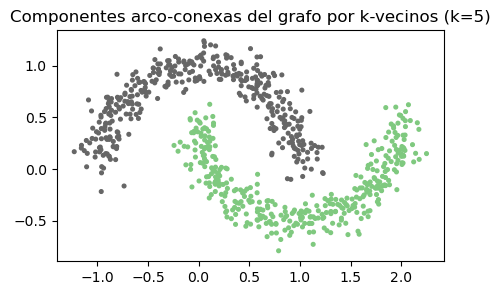

Numero de componentes encontradas: 2


In [4]:
k = 5 # Selecciona un valor de k apropiado

# Esta linea calcula la matriz de adyacencia del grafo de k-vecinos mas cercanos
knn_adjacency_matrix = kneighbors_graph(X, k).toarray()

# calculamos las componentes arco-conexas resultantes
n_components_knn, c_labls = connected_components(knn_adjacency_matrix, directed=False, return_labels=True)

# graficamos los puntos coloreados por su componente arco-conexa
plt.figure(figsize=(5, 3))
plt.scatter(X[:, 0], X[:, 1], c=c_labls, s=7, cmap='Accent')
plt.title(f'Componentes arco-conexas del grafo por k-vecinos (k={k})')
plt.show()
print(f'Numero de componentes encontradas: {n_components_knn}')

---

**Hacer:** De acuerdo a los resultados anteriores, cual metodo ($k$-vecinos o $\varepsilon$-grafos) es mas efectivo? Porque?

**Tu respuesta:**

---

## **2. Aplicacion: Agrupamiento de digitos**

En la celda siguiente cargamos los datos de los digitos con etiqueta 1.

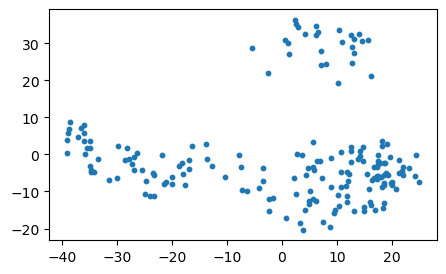

In [5]:
# De el modulo de datasets de scikit learn, importar la funcion digits
from sklearn.datasets import load_digits

# Importar el conjunto de datos de digitos
digits = load_digits()

# Separamos los datos y sus etiquetas (i.e., el numero)
X = digits.data
etiquetas = digits.target

from sklearn.decomposition import PCA

indices = np.where(etiquetas==1)[0]

X = X[indices]
# PCA 2D solo para los  1's
pca = PCA(n_components=2)
proj = pca.fit_transform(X)

# Graficamos la proyeccion PCA 2D de los 1's
plt.figure(figsize=(5, 3))
plt.scatter(proj[:,0],proj[:,1], s=10)
plt.show()

**Hacer:** En la celda de abajo, utiliza lo aprendido para agrupar los diferentes tipos de 1's en el conjunto de datos de digitos. Pudiste lograrlo? Cuales fueron las innovaciones que incluiste?


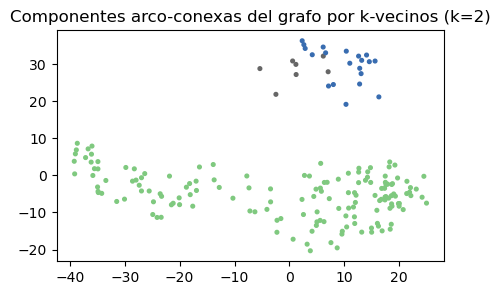

Numero de componentes encontradas: 3


In [6]:
# tu codigo aqui

k = 2 # Selecciona un valor de k apropiado

# Esta linea calcula la matriz de adyacencia del grafo de k-vecinos mas cercanos
knn_adjacency_matrix = kneighbors_graph(X, k).toarray()

# calculamos las componentes arco-conexas resultantes
n_components_knn, c_labls = connected_components(knn_adjacency_matrix, directed=False, return_labels=True)

# graficamos los puntos coloreados por su componente arco-conexa
plt.figure(figsize=(5, 3))
plt.scatter(proj[:, 0], proj[:, 1], c=c_labls, s=7, cmap='Accent')
plt.title(f'Componentes arco-conexas del grafo por k-vecinos (k={k})')
plt.show()
print(f'Numero de componentes encontradas: {n_components_knn}')

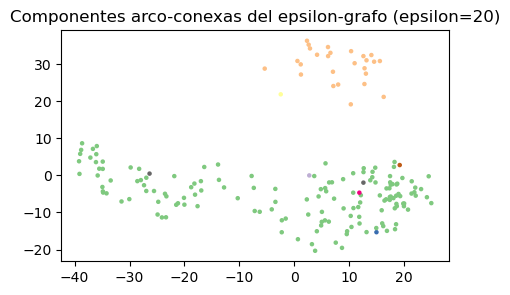

Numero de componentes encontradas: 9


In [7]:
# tu codigo aqui

epsilon = 20 # Slecciona un valor de epsilon apropiado

# Esta linea calcula la matriz de adyacencia del epsilon-grafo
adjacency_matrix = radius_neighbors_graph(X, epsilon).toarray()

# Ahora calculamos las componentes arco-conexas resultantes
n_components, cluster_labels = connected_components(adjacency_matrix, directed=False, return_labels=True)

# Finalmente, graficamos los puntos coloreados por su componente arco-conexa
plt.figure(figsize=(5, 3))
plt.scatter(proj[:, 0], proj[:, 1], c=cluster_labels, s = 5, cmap='Accent')
plt.title(f'Componentes arco-conexas del epsilon-grafo (epsilon={epsilon})')
plt.show()
print(f'Numero de componentes encontradas: {n_components}')

---

### Usando la distancia de Fermat

Para datos $X \subseteq \mathbb{R}^n$, una constante $\alpha \geq 1$ y puntos $\mathbf{x}, \mathbf{y} \in X$, la distancia (numerica) de Fermat es 

$$D_{X,\alpha}(\mathbf{x}, \mathbf{y} ) = \inf_\Gamma \left\{\sum_{i = 0}^{I-1} \|\mathbf{x}_i - \mathbf{x}_{i+1}\|_2^ \alpha \; : \; \Gamma = (\mathbf{x} =
\mathbf{x}_0 , \mathbf{x}_1 ,\ldots, \mathbf{x}_{I-1}, \mathbf{x}_I = \mathbf{y}) \in X^{I+1} , \;\; I \in \mathbb{N}\right\}$$


Esta distancia es un estimador consistente [2, Teorema 2.3] de la cantidad 

$$\mathcal{D}_{f,\beta} (\mathbf{x} , \mathbf{y}) = \inf_\gamma \int_\gamma \frac{1}{f^\beta} \, d\ell $$

donde $\beta \geq 1$ es una constante (relacionada a $\alpha$ via $\alpha = n\beta + 1$), $f : S \longrightarrow [m_f , M_f]$ es una funcion de intensidad (e.g., densidad) para $m_f > 0 $, $S \subseteq \mathbb{R}^n$ es un subconjunto abierto y conexo con frontera $C^1$ (e.g., vacia),  el infimo es tomado sobre todas las curvas rectificables $\gamma : [a,b] \longrightarrow \bar{S} $ con $\mathbf{x} = \gamma(a) $,  $\mathbf{y} = \gamma(b)$, y los datos $X$ son muestreados de acuerdo a $f$. 

[1] https://www.aristas.com.ar/fermat/fermat.html

[2] Nonhomogeneous Euclidean first-passage percolation and distance learning, https://arxiv.org/abs/1810.09398

In [ ]:
# Remover el numeral de la linea de abajo para instalar el paquete fermat

# !pip install fermat

In [8]:
from fermat import Fermat
from scipy.spatial import distance_matrix

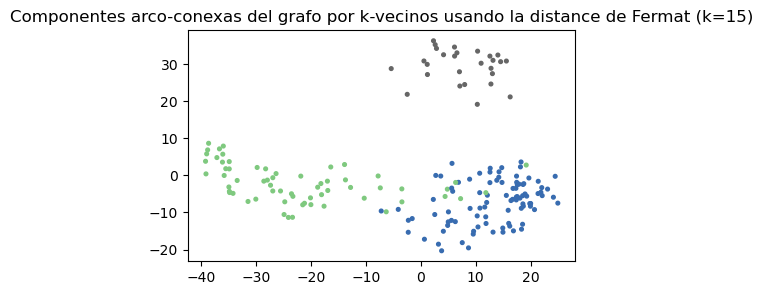

Numero de componentes encontradas: 3


In [9]:
k_vecinos_fermat = 3
k_vecinos_clusters = 15
alpha_valor = 25

# Primero calculamos la distancia de Fermat 
f = Fermat(alpha = alpha_valor, path_method='FW', k=k_vecinos_fermat)
f.fit(distance_matrix(X,X))
fermat_distances = f.get_distances() 

# Esta linea calcula la matriz de adyacencia del grafo de k-vecinos mas cercanos usando la distancia de Fermat calculada
knn_adjacency_matrix = kneighbors_graph(fermat_distances, n_neighbors = k_vecinos_clusters, metric = 'precomputed').toarray()

# calculamos las componentes arco-conexas resultantes
n_components_knn, c_labls = connected_components(knn_adjacency_matrix, directed=False, return_labels=True)

# graficamos los puntos coloreados por su componente arco-conexa
plt.figure(figsize=(5, 3))
plt.scatter(proj[:, 0], proj[:, 1], c=c_labls, s=7, cmap='Accent')
plt.title(f'Componentes arco-conexas del grafo por k-vecinos usando la distance de Fermat (k={k_vecinos_clusters})')
plt.show()
print(f'Numero de componentes encontradas: {n_components_knn}')

